## Human Activity Recognition for Healthy Lifestyle Monitoring

This project focuses on building a machine learning pipeline to classify five basic human activities: sitting down, standing up, walking, running, and climbing stairs—using smartphone sensor data (accelerometer, gyroscope, gravity).  

**Background and Relevance :**
Human Activity Recognition (HAR) using wearable sensors plays a key role in modern health monitoring, as seen in fitness trackers and smartwatches. Reliable detection of daily activities can support healthy lifestyle interventions, especially for elderly populations. This assignment focuses on five core activities, sitting down, standing up, walking, running, and climbing stairs, to explore how sensor-based data can be transformed into actionable insights for wellness and digital health applications.

**Aim and Research Questions :**
The goal is to develop and evaluate machine learning models that classify these activities using smartphone sensor data to support healthy lifestyle monitoring.

Key questions to address:
1. Which sensor-derived features best distinguish the five target activities?
2. How do supervised vs. unsupervised learning approaches compare for this classification task?
3. Which model achieves the highest accuracy and reliability when combined with appropriate feature extraction and selection?
4. What are the practical considerations and limitations for deploying such systems in real-world health monitoring contexts?


Import Libraries:

In [4]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [17]:
import sys
import os
from pathlib import Path
import pandas as pd
import importlib
import  shutil
import matplotlib.pyplot as plt
import numpy as np
import warnings
warnings.filterwarnings("ignore")

# Add the src folder to the Python module search path
sys.path.append(os.path.abspath("src"))
PROJECT_ROOT = Path.cwd().resolve()
RAW_BASE   = PROJECT_ROOT / "data" / "raw"
TRIMMED_BASE = PROJECT_ROOT / "data" / "trimmed_data"

from data_loader import *
from visualization import *
from preprocessing import *

# Load all data into memory
all_data = load_all_data(RAW_BASE, print_option=False)

Data Loaded
Raw Data Classes: ['running', 'sit_down', 'stairs', 'stand_up', 'walking']


### Data Collection Procedure

We used two different methods for collecting activity data:

1. **Continuous recordings**  
   - Applied to activities such as **running, walking, and climbing stairs**.  
   - These activities can be performed continuously without interruption.  
   - As a result, the recordings are relatively long.

     **Recording Procedure:** The smartphone was secured on the subject’s left upper arm while standing still. The recording began in this position, after which the subject performed the activity, running, walking, or climbing stairs, in a straight line. Once the activity was completed, the subject remained still until the recording was stopped.
     
2. **Single-instance recordings**  
   - Applied to **sitting down** and **standing up** activities.  
   - Each recording contains **only one instance** of the activity.  
   - These recordings are therefore relatively short.

     **Recording Procedure:** For the sitting-down activity, the smartphone was secured on the subject’s left arm while they stood still in front of a chair. Recording began, and after 1–2 seconds the subject performed the sitting-down action. The recording continued for another 1–2 seconds while the subject remained seated, then was stopped. The same procedure was followed for the standing-up activity.

Below are the visualized plots of **raw** accelerometer, gyroscope, and gravity sensor recordings from randomly selected samples of each activity group.

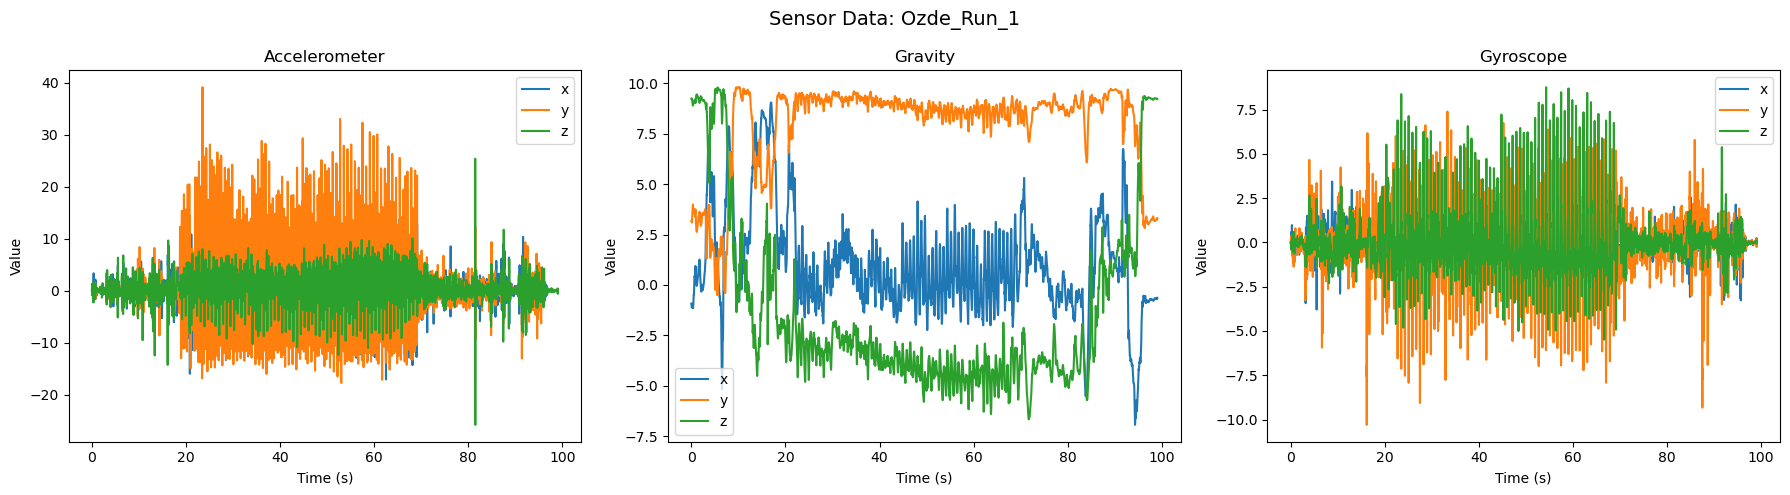

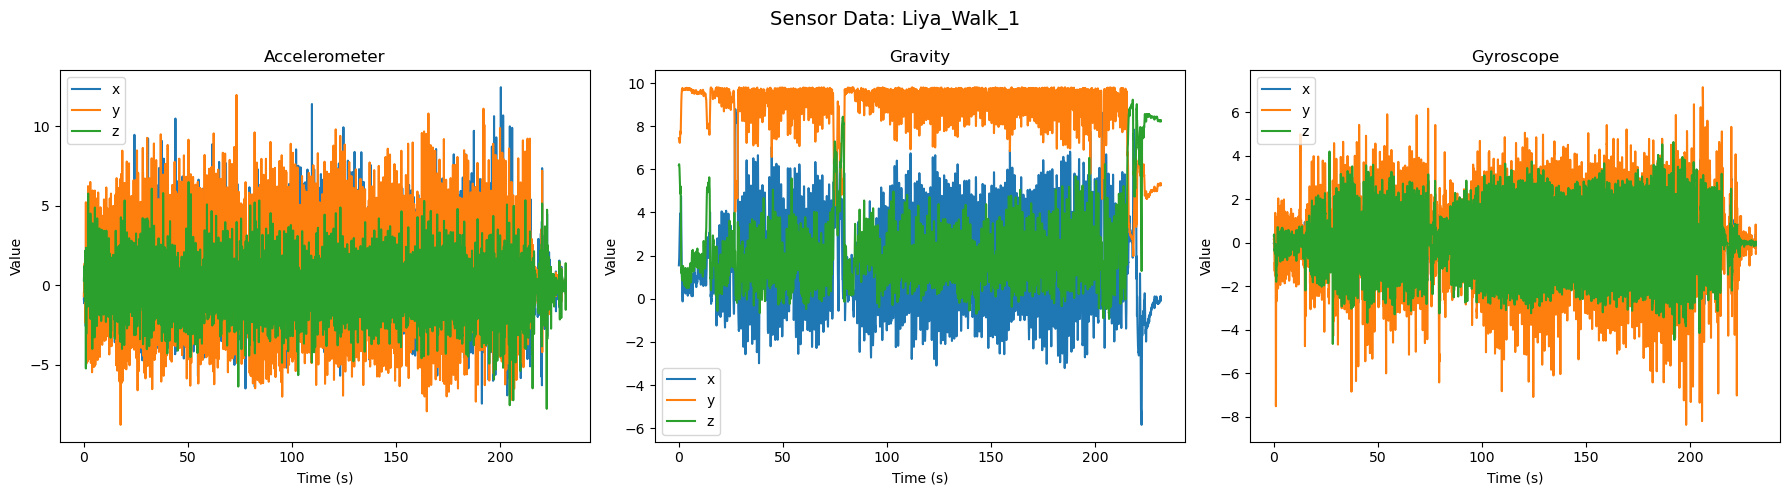

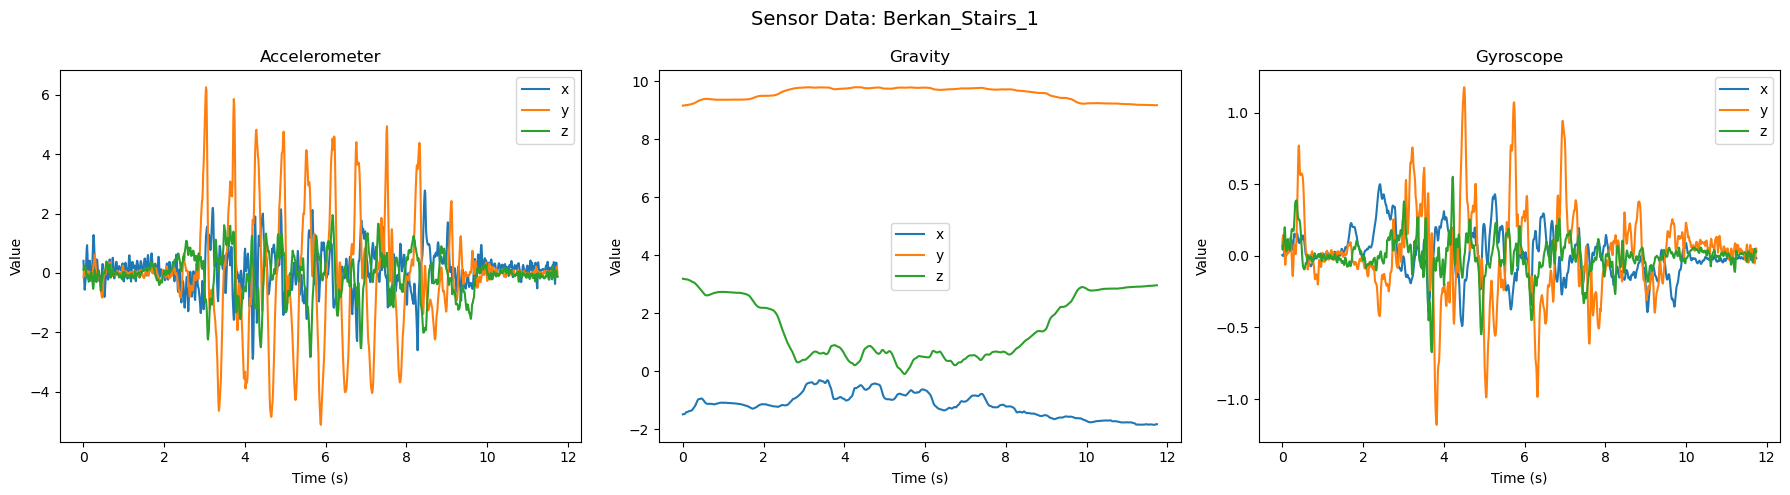

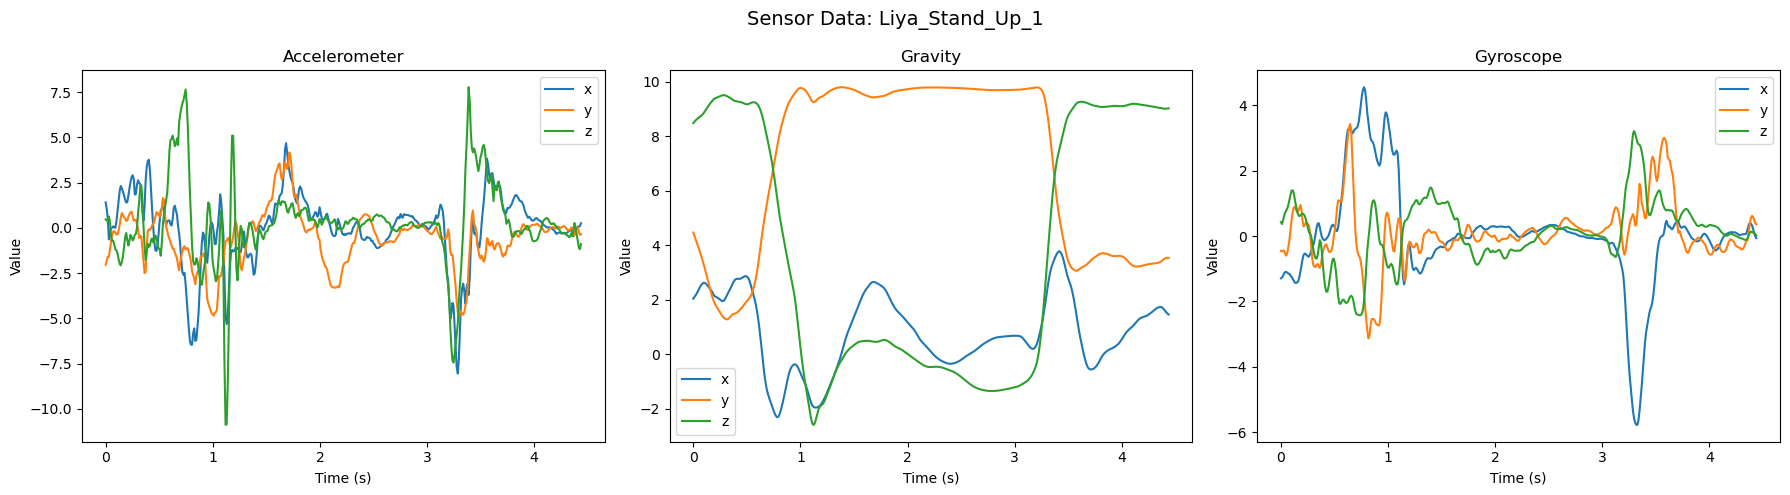

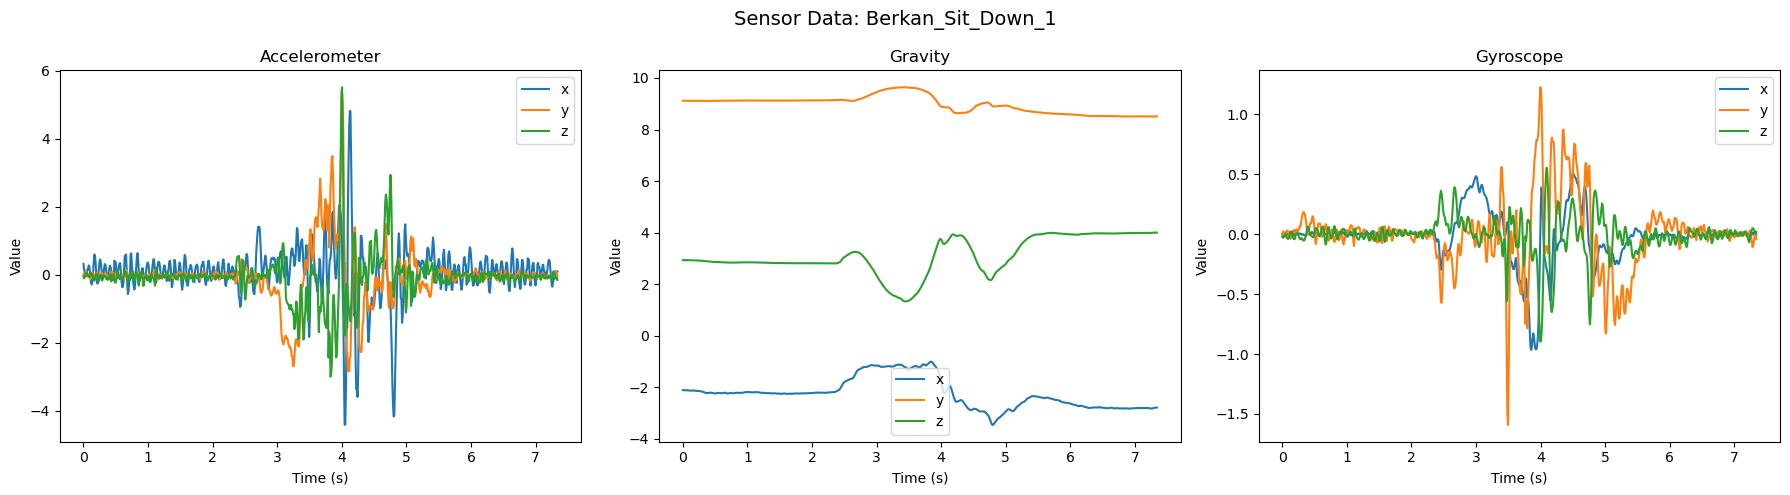

In [6]:
plot_activity(RAW_BASE / "running" / "Ozde_Run_1")
plot_activity(RAW_BASE / "walking" / "Liya_Walk_1")
plot_activity(RAW_BASE / "stairs" / "Berkan_Stairs_1")
plot_activity(RAW_BASE / "stand_up" / "Liya_Stand_Up_1")
plot_activity(RAW_BASE / "sit_down" / "Berkan_Sit_Down_1")

The three sensors used to measure the data consists of the following: 

1. Accelerometer: Measures linear acceleration of the body in three axes (x, y, z) capturing movement intensity such as steps.

2. Gravity Sensor: Detects the orientation and tilt of the body relative to the Earth's gravity. 

3. Gyroscope: Measures angular velocity or rotational motion around the three axes. This allows twists and turns to be captured.

We start processing the raw data by first removing the inactive segments at the beginning and end of each recording, retaining only the portion where the activity is actually performed.
Additionally, we discard any segments recorded while placing the phone into the armband, as these movements do not represent the target activity.

The following observations were made with respect to the activities below:

- Running: 

The accelerometer and gyroscope signals in the middle phase which is the region of interest, display strong, rhythmic oscillations which correspond to foot strikes and body rotation during a run. The gravity sensor remains relatively stable, indicating consistent sensor orientation.

- Walking:
The walking sensor data shows relatively consistent, lower-amplitude oscillations compared to running. This reflects the slower and steadier pattern obtained during walking. The accelerometer and gyroscope signals maintain moderate fluctuations throughout most of the session, lacking the sharp spikes seen in running, and the gravity readings remain mostly stable with small shifts due to subtle changes in orientation. This steadiness highlights the lower-impact, motion characteristic of walking.

- Stairs: 
The stairs activity shows more ryhthmic and high-amplitude oscillations in the accelerometer, especially in the y-axis, which captures the vertical up-and-down motion of climbing. Compared to walking, these oscillations are more intense but less erratic than running. The gyroscope data also shows bursts of angular motion that align with the steps taken. This is an indication of frequent shifts in leg and body orientation. Meanwhile, the gravity signals change gradually over time, reflecting the tilt of the body as the subject moves upward and then stabilizes when standing still. This pattern highlights the stepwise, periodic nature of stair climbing.

- Standing up:
The standing-up motion shows short and sharp bursts in the accelerometer, especially in the z-axis. This corresponds to the quick upward push off the chair. The gyroscope data reflects strong angular movements at the start and end of the motion. Most likely reflecting the movement of the body as it leans forward and then straightens. The gravity signals exhibit a clear transition, with all three axes shifting rapidly, showing the change from a seated to an upright posture. This pattern highlights a brief event followed by stability once the position is fully standing.

- Sitting down:
The sitting-down motion shows again a short and intense burst in the accelerometer signals, most prominently in the x and z axes. This corresponds to the controlled descent into the seat. The gyroscope data captures angular rotation during the leaning phase, peaking around the midpoint of the motion before stabilizing. The gravity plot shows a gradual transition for tilt as the body transitions from upright to seated, with the z-axis increasing and the x-axis decreasing, this clearly marks the posture change.





- **For Continuous activities (running / walking / climbing stairs):** Each recording was trimmed to remove non-activity segments and then divided into multiple data samples using 3-second windows with 50% overlap.

All three trimming functions work the same way. They automatically detect when the activity starts and ends by measuring how strong the motion signal is.

- For running and walking the y-axis of the accelerometer is used. The RMS (energy) is calculated by sliding a short window across the signal.

- For stairs, the gravity signal's magnitude is used, since body tilt changes more clearlycapturing stair climbing.

- A specific threshold was defined for each funciton that is used to make the initial cut when the first treshold is passed and one to make the second trim when the RMS value falls below the second treshold value.

Each trimming function can generate a debug plot that shows the sensor signal, the RMS energy curve, the start/end thresholds, and vertical lines marking the detected trim boundaries.
These plots are extremely useful to visually confirm that the automatic cuts are correct; you should see the trim markers line up with the start and end of the actual activity burst.

In [7]:
WINDOW_SIZE = 3.0 #Seconds

preprocess_running(TRIMMED_BASE, all_data, window_size=WINDOW_SIZE, show_plots=False) # show_plots=False to disable plots
preprocess_walking(TRIMMED_BASE, all_data, window_size=WINDOW_SIZE, show_plots=False) # show_plots=False to disable plots
preprocess_stairs(TRIMMED_BASE, all_data, window_size=WINDOW_SIZE, show_plots=False)  # show_plots=False to disable plots


 Processing running | Folder: Berkan_Run_1
  Trim 7.50 → 65.90, 38 windows, saved in C:\Users\yusuf\Documents\Python_Projects\Data-Analytics-and-Learning-Methods\data\trimmed_data\running

 Processing running | Folder: Berkan_Run_2
  Trim 7.51 → 67.41, 39 windows, saved in C:\Users\yusuf\Documents\Python_Projects\Data-Analytics-and-Learning-Methods\data\trimmed_data\running

 Processing running | Folder: Ozde_Run_1
  Trim 20.96 → 67.26, 29 windows, saved in C:\Users\yusuf\Documents\Python_Projects\Data-Analytics-and-Learning-Methods\data\trimmed_data\running

 Processing running | Folder: Ozde_Run_2
  Trim 12.00 → 82.19, 45 windows, saved in C:\Users\yusuf\Documents\Python_Projects\Data-Analytics-and-Learning-Methods\data\trimmed_data\running

 Processing running | Folder: Ozde_Run_3
  Trim 19.47 → 80.70, 39 windows, saved in C:\Users\yusuf\Documents\Python_Projects\Data-Analytics-and-Learning-Methods\data\trimmed_data\running

 Processing running | Folder: Ozde_Run_4
  Trim 17.98 → 7

Example plot of the RMS Intersection Based Trim Detection Procedure for Raw Running Recordings:

![](figures\running_rms_intersection_based_trim_detection.png)

Initial trim is made when the initial value passes the starting treshold value and the ending trim is done when the RMS value drops below the defined end trim. The corresponding cuts can be seen on the accelerometer plot where you can see that the cuts dont include the initial and end noise captured before and after the activity is taking place

Example plot of the RMS Intersection Based Trim Detection Procedure for Raw Walking Recordings:

![](figures\walking_rms_intersection_based_trim_detection.png)

[Explanation of this plot goes here: How the RMS energy used to find the trimming points etc.]

Here the corresponding accelerometer plot can also be visualized with the RMS plots for one of the stairs data. It can be seen that the trims do not capture the noise present at the start and end of the raw data.
![](figures/rms_intersection.png)  
![](figures/corresponding_rms_trim_accl.png)



- **For single-instance activities (sit-down / stand-up):**
Each single-instance activity (sit-down / stand-up) was trimmed to a 3-second window, centered on the activity itself, to remove non-activity segments.

In [8]:
WINDOW_SIZE = 3.0 #Seconds

results = trim_sitdown_standup(RAW_BASE, TRIMMED_BASE, window_size=WINDOW_SIZE)

Done. Processed: 60 | Skipped: 0


[An explanation of the trimming procedure of sitdown and standup activities will added here with a plot]

Now we can collect all windowed activity data into a single CSV file.

[Also Explain which/why features are extracted from x, y and z sensor recordings]

In [9]:
from create_csv import *

DATASET_PATH = PROJECT_ROOT / "dataset.csv"

audit_windows(TRIMMED_BASE)
df = build_dataset_from_windowed_data(TRIMMED_BASE, DATASET_PATH, keep_ids=True)

[Audit]
  - running: expected=276, usable=276, skipped=0, reasons={'missing_acc': 0, 'missing_gyro': 0, 'missing_grav': 0, 'bad_csv': 0, 'no_xyz': 0}
  - sit_down: expected=30, usable=30, skipped=0, reasons={'missing_acc': 0, 'missing_gyro': 0, 'missing_grav': 0, 'bad_csv': 0, 'no_xyz': 0}
  - stairs: expected=39, usable=39, skipped=0, reasons={'missing_acc': 0, 'missing_gyro': 0, 'missing_grav': 0, 'bad_csv': 0, 'no_xyz': 0}
  - stand_up: expected=30, usable=30, skipped=0, reasons={'missing_acc': 0, 'missing_gyro': 0, 'missing_grav': 0, 'bad_csv': 0, 'no_xyz': 0}
  - walking: expected=481, usable=481, skipped=0, reasons={'missing_acc': 0, 'missing_gyro': 0, 'missing_grav': 0, 'bad_csv': 0, 'no_xyz': 0}

Total window folders: 856 | Usable (all three files OK): 856

[Activity] running
  Processed 250 windows...

[Activity] sit_down

[Activity] stairs

[Activity] stand_up

[Activity] walking
  Processed 500 windows...
  Processed 750 windows...

[Done] Wrote 856 rows × 167 columns to: C:

## Load the dataset
- First column is label (y)
- Remaining are features (X)

In [10]:
DATASET_PATH = PROJECT_ROOT / "dataset.csv"

df = pd.read_csv(DATASET_PATH)

X = df.iloc[:, 1:]
y = df.iloc[:, 0]

print("Loaded dataset.csv with shape:", df.shape)
print("Target name:", df.columns[0])
print("Num features:", X.shape[1])

df.head(3)# 12345

Loaded dataset.csv with shape: (856, 167)
Target name: activity
Num features: 166


,activity,acc_corr_x_y,acc_corr_x_z,acc_corr_y_z,acc_mag_dom_freq,acc_mag_iqr,acc_mag_kurtosis,acc_mag_max,acc_mag_mean,acc_mag_median,...,gyro_z_mean,gyro_z_median,gyro_z_min,gyro_z_rms,gyro_z_skew,gyro_z_spec_centroid,gyro_z_spec_energy,gyro_z_spec_entropy,gyro_z_std,person
0,running,-0.422285,-0.255755,-0.025324,5.0,6.662222,-0.093018,23.414247,9.195592,9.040583,...,-0.017501,-0.035374,-1.221355,0.420798,0.278885,4.202507,11.759396,3.036354,0.421137,Berkan
1,running,-0.068380,-0.043782,-0.262769,5.0,5.756685,-0.737154,18.871659,9.020759,9.577971,...,0.038710,0.124412,-1.495412,0.619739,-0.194350,2.548933,19.232855,2.127987,0.619562,Berkan
2,running,-0.110942,0.009237,-0.290851,5.0,5.511045,-0.709310,17.660803,8.971730,9.589745,...,0.085773,0.187724,-1.495412,0.598747,-0.249874,2.659217,22.169449,2.251347,0.593562,Berkan


## Split data into Train and Test set
We split the data into training and test datsets with a 80/20 train/test ratio. This is done in a stratified manner. Afterwards we scale the data for effective training.


In [11]:
# imports
from sklearn.preprocessing import StandardScaler
from preprocessing import stratified_person_label_split

X_train, y_train, X_test, y_test, info = stratified_person_label_split(X,y,test_ratio=0.20,random_state=42)

print(info["sizes"])
print(info["ratios"])
print("Classes:", info["class_dist"])
print("People:", info["person_dist"])

# --- StandardScaler setup ---
scaler = StandardScaler()

print(X_train.dtypes)
print(X_train.head())

# Keep only numeric columns
X_train_num = X_train.select_dtypes(include=["number"])
X_test_num  = X_test.select_dtypes(include=["number"])

# Scale numeric features only
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train_num),
    columns=X_train_num.columns,
    index=X_train.index)

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test_num),
    columns=X_test_num.columns,
    index=X_test.index)


{'train': 685, 'test': 171, 'total': 856}
{'train': 0.8002336448598131, 'test': 0.19976635514018692}
Classes: {'train': {'running': 221, 'sit_down': 24, 'stairs': 31, 'stand_up': 24, 'walking': 385}, 'test': {'running': 55, 'sit_down': 6, 'stairs': 8, 'stand_up': 6, 'walking': 96}}
People: {'train': {'Berkan': 131, 'Liya': 329, 'Ozde': 225}, 'test': {'Berkan': 33, 'Liya': 82, 'Ozde': 56}}
acc_corr_x_y            float64
acc_corr_x_z            float64
acc_corr_y_z            float64
acc_mag_dom_freq        float64
acc_mag_iqr             float64
                         ...   
gyro_z_spec_centroid    float64
gyro_z_spec_energy      float64
gyro_z_spec_entropy     float64
gyro_z_std              float64
person                   object
Length: 166, dtype: object
     acc_corr_x_y  acc_corr_x_z  acc_corr_y_z  acc_mag_dom_freq  acc_mag_iqr  \
261     -0.017045      0.295344     -0.266787          4.983389     8.331910   
542     -0.223268      0.183530      0.328016          1.010101     2

# Feature Selection
- **Filter Methods:** Variance -> Correlation -> Mutual Information
- **Wrapper Methods:** Recursive Feature Elimination (RFE) + Sequential Feature Selection (SFS) forward/backward

All performed on `dataset.csv` (explained above how this dataset is obtained).


In [13]:
## Imports & Code Paths 

import numpy as np
import matplotlib.pyplot as plt

from sklearn.feature_selection import VarianceThreshold, SelectKBest, mutual_info_classif
from sklearn.feature_selection import RFE, SequentialFeatureSelector
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_validate
from sklearn.metrics import make_scorer, accuracy_score, cohen_kappa_score, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.base import clone
from sklearn.decomposition import PCA
from functools import partial
from sklearn.metrics import accuracy_score, silhouette_score 
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score


# Our feature selection toolkit (from feature_selection.py)
from feature_selection import (
    filter_select,
    wrapper_select,
    plot_correlation_heatmap,
    accuracy_vs_k_MI,
    #pca_explained_variance
)

import os
# Paths & directories (safe to run multiple times)
# (Creates ./figures if it doesn't exist for saved plots)
os.makedirs("figures", exist_ok=True)


## Filter Methods
We use 3 filters succesively:
- **Variance:** Removes exactly-constant (dead) features
- **Correlation:** Drop one of each highly correlated pair of features
- **Mutual Information (MI):** Keep top-K features by MI with class labels 

In [14]:
# FILTERS: variance -> correlation -> MI-KBest
Xf_train, names_f, report = filter_select(
    X_train_scaled, y_train,
    variance_thresh=0.0,       #threshold for removing ONLY exactly-constant features
    corr_thresh=0.90,          #feature-feature absolute correlation threshold
    k_best=40,                 #integer: keep top-k by mutual information; None to skip
    scale_for_mi=True,         
    mi_n_neighbors=5,          #how many neighbors to use for MI selection
    mi_random_state=42         #fixed random_state for reproducibility
)
print("Filter report:", report)

# Apply same feature subset to both train and test
X_train_fs = X_train_scaled[names_f]
X_test_fs  = X_test_scaled[names_f]

[VarianceThreshold] Kept: 165, Removed: 0
[CorrelationFilter] Kept: 108, Removed: 57 (|r| > 0.9)
Removed highly correlated features: ['acc_mag_max', 'acc_mag_mean', 'acc_mag_median', 'acc_mag_rms', 'acc_mag_spec_energy', 'acc_mag_std', 'acc_x_min', 'acc_x_rms', 'acc_x_spec_energy', 'acc_x_std', 'acc_y_iqr', 'acc_y_max', 'acc_y_min', 'acc_y_rms', 'acc_y_spec_energy', 'acc_y_std', 'acc_z_iqr', 'acc_z_mean', 'acc_z_median', 'acc_z_rms', 'acc_z_spec_energy', 'acc_z_std', 'grav_mag_iqr', 'grav_mag_max', 'grav_mag_median', 'grav_mag_rms', 'grav_mag_spec_energy', 'grav_mag_std', 'grav_x_median', 'grav_x_spec_energy', 'grav_x_std', 'grav_y_median', 'grav_y_rms', 'grav_y_std', 'grav_z_max', 'grav_z_mean', 'grav_z_median', 'grav_z_min', 'grav_z_std', 'gyro_mag_max', 'gyro_mag_median', 'gyro_mag_rms', 'gyro_mag_spec_energy', 'gyro_mag_std', 'gyro_x_spec_energy', 'gyro_x_std', 'gyro_y_max', 'gyro_y_rms', 'gyro_y_spec_energy', 'gyro_y_std', 'gyro_z_iqr', 'gyro_z_max', 'gyro_z_min', 'gyro_z_rms', 'g

Baseline CV performance (5-fold, training set only):

LogisticRegression:
  Accuracy : 0.9796 ± 0.0107
  Kappa    : 0.9646 ± 0.0185
  F1-macro : 0.9220 ± 0.0386

KNN:
  Accuracy : 0.9737 ± 0.0127
  Kappa    : 0.9546 ± 0.0219
  F1-macro : 0.8956 ± 0.0612

NaiveBayes:
  Accuracy : 0.9372 ± 0.0164
  Kappa    : 0.8949 ± 0.0245
  F1-macro : 0.8405 ± 0.0457

DecisionTree:
  Accuracy : 0.9796 ± 0.0097
  Kappa    : 0.9647 ± 0.0162
  F1-macro : 0.9342 ± 0.0304


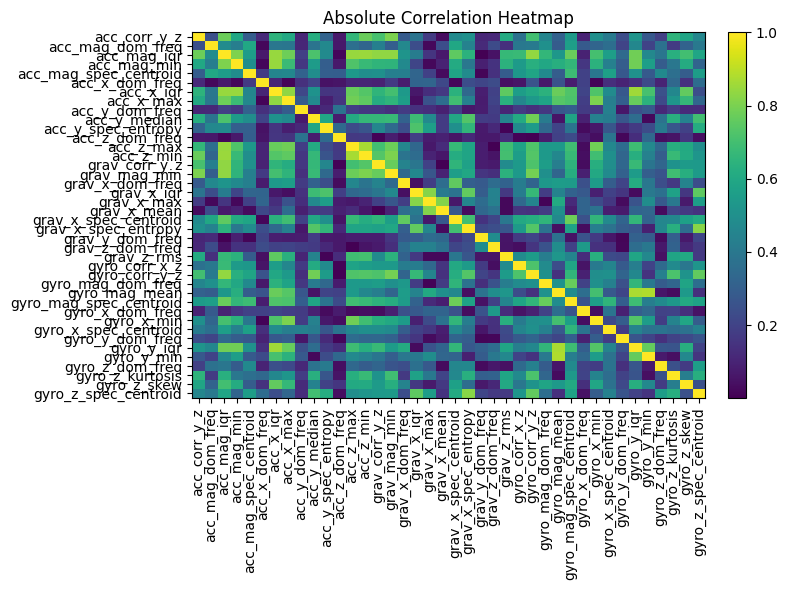

Saved correlation heatmap to corr_heatmap.png


In [20]:
#Intermediate Results
#Baseline models on filtered features (accuracy on held-out test set )
models = {
    "LogisticRegression": LogisticRegression(max_iter=5000, solver="lbfgs", random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "NaiveBayes": GaussianNB(),
    "DecisionTree": DecisionTreeClassifier(random_state=42)
}

# Define custom scorers
scorers = {
    "accuracy": make_scorer(accuracy_score),
    "kappa": make_scorer(cohen_kappa_score),
    "f1_macro": make_scorer(f1_score, average="macro")  # macro for multiclass
}

print("Baseline CV performance (5-fold, training set only):")
for name, clf in models.items():
    cv_results = cross_validate(clf, X_train_fs.values, y_train, cv=cv, scoring=scorers)
    acc_mean, acc_std = cv_results["test_accuracy"].mean(), cv_results["test_accuracy"].std()
    kappa_mean, kappa_std = cv_results["test_kappa"].mean(), cv_results["test_kappa"].std()
    f1_mean, f1_std = cv_results["test_f1_macro"].mean(), cv_results["test_f1_macro"].std()

    print(f"\n{name}:")
    print(f"  Accuracy : {acc_mean:.4f} ± {acc_std:.4f}")
    print(f"  Kappa    : {kappa_mean:.4f} ± {kappa_std:.4f}")
    print(f"  F1-macro : {f1_mean:.4f} ± {f1_std:.4f}")

# Optional: visualize correlation after variance filtering
# Correlation heatmap (saved to figures/, non-blocking)
plot_correlation_heatmap(pd.DataFrame(Xf_train, columns=names_f), show=True, block=False, save_path="figures/corr_heatmap.png")
print("Saved correlation heatmap to corr_heatmap.png")

## Wrapper Methods
XXXXX

In [ ]:
# Wrapper: RFE + Logistic Regression (CV summary on train only)
Xw_lr_train, names_lr, info_lr = wrapper_select(
    X_train_fs, y_train,
    method="rfe",
    n_features_to_select=min(15, X_train_fs.shape[1]),
    estimator=LogisticRegression(max_iter=5000, solver="lbfgs", random_state=42),
    cv_splits=5,
    scale_inputs=True
)

[Wrapper-RFE] Kept: 15 features
  Accuracy : 0.9956 ± 0.0058
  Kappa    : 0.9923 ± 0.0103
  F1-macro : 0.9881 ± 0.0160
  Selected features: ['acc_corr_y_z', 'acc_mag_dom_freq', 'acc_mag_iqr', 'acc_mag_spec_centroid', 'acc_y_dom_freq', 'acc_y_median', 'acc_y_spec_entropy', 'grav_corr_y_z', 'gyro_corr_x_z', 'gyro_mag_mean', 'gyro_mag_spec_centroid', 'gyro_x_min', 'gyro_y_iqr', 'gyro_z_skew', 'gyro_z_spec_centroid']
RFE + LR selected: ['acc_corr_y_z', 'acc_mag_dom_freq', 'acc_mag_iqr', 'acc_mag_spec_centroid', 'acc_y_dom_freq', 'acc_y_median', 'acc_y_spec_entropy', 'grav_corr_y_z', 'gyro_corr_x_z', 'gyro_mag_mean', 'gyro_mag_spec_centroid', 'gyro_x_min', 'gyro_y_iqr', 'gyro_z_skew', 'gyro_z_spec_centroid']
  Accuracy : 0.9956 ± 0.0058
  F1-macro : 0.9881 ± 0.0160
  Kappa    : 0.9923 ± 0.0103


In [22]:
# Wrapper: SFS (forward) + KNN (works well for distance-based models)
Xw_knn_train, names_knn, info_knn = wrapper_select(
    X_train_fs, y_train,
    method="sfs_forward",
    n_features_to_select=min(15, X_train_fs.shape[1]),
    estimator=KNeighborsClassifier(n_neighbors=5),
    cv_splits=5,
    scale_inputs=True
)

[Wrapper-SFS:forward] Kept: 15 features
  Accuracy : 0.9956 ± 0.0058
  F1-macro : 0.9875 ± 0.0170
  Kappa    : 0.9923 ± 0.0102
  Selected features: ['acc_mag_dom_freq', 'acc_mag_iqr', 'acc_mag_min', 'acc_x_iqr', 'acc_x_max', 'acc_y_dom_freq', 'acc_y_median', 'acc_y_spec_entropy', 'acc_z_max', 'grav_x_iqr', 'grav_x_mean', 'gyro_corr_y_z', 'gyro_mag_mean', 'gyro_x_spec_centroid', 'gyro_y_iqr']


In [25]:
# Wrapper: SFS (forward) + Naive Bayes
Xw_nb_train, names_nb, info_nb = wrapper_select(
    X_train_fs, y_train,
    method="sfs_forward",
    n_features_to_select=min(15, X_train_fs.shape[1]),
    estimator=GaussianNB(),
    cv_splits=5,
    scale_inputs=True
)

[Wrapper-SFS:forward] Kept: 15 features
  Accuracy : 0.9942 ± 0.0055
  F1-macro : 0.9754 ± 0.0293
  Kappa    : 0.9898 ± 0.0095
  Selected features: ['acc_corr_y_z', 'acc_mag_dom_freq', 'acc_mag_iqr', 'acc_mag_spec_centroid', 'acc_y_dom_freq', 'acc_y_median', 'acc_y_spec_entropy', 'grav_corr_y_z', 'grav_x_mean', 'grav_y_dom_freq', 'grav_z_rms', 'gyro_corr_x_z', 'gyro_mag_dom_freq', 'gyro_x_min', 'gyro_y_iqr']


In [26]:
# Wrapper: RFE + Decision Tree (trees don't need scaling)
Xw_dt_train, names_dt, info_dt = wrapper_select(
    X_train_fs, y_train,
    method="rfe",
    n_features_to_select=min(15, X_train_fs.shape[1]),
    estimator=DecisionTreeClassifier(random_state=42),
    cv_splits=5,
    scale_inputs=False
)

[Wrapper-RFE] Kept: 15 features
  Accuracy : 0.9825 ± 0.0099
  Kappa    : 0.9699 ± 0.0165
  F1-macro : 0.9394 ± 0.0256
  Selected features: ['acc_mag_iqr', 'acc_x_dom_freq', 'acc_x_iqr', 'acc_x_max', 'acc_y_dom_freq', 'acc_y_median', 'acc_y_spec_entropy', 'gyro_mag_dom_freq', 'gyro_mag_mean', 'gyro_mag_spec_centroid', 'gyro_x_dom_freq', 'gyro_x_min', 'gyro_x_spec_centroid', 'gyro_y_dom_freq', 'gyro_y_iqr']


[VarianceThreshold] Kept: 165, Removed: 0
[CorrelationFilter] Kept: 128, Removed: 37 (|r| > 0.95)
Removed highly correlated features: ['acc_mag_mean', 'acc_mag_median', 'acc_mag_rms', 'acc_mag_spec_energy', 'acc_mag_std', 'acc_x_rms', 'acc_x_spec_energy', 'acc_x_std', 'acc_y_iqr', 'acc_y_max', 'acc_y_min', 'acc_y_rms', 'acc_y_spec_energy', 'acc_y_std', 'acc_z_iqr', 'acc_z_median', 'acc_z_rms', 'acc_z_spec_energy', 'acc_z_std', 'grav_mag_rms', 'grav_mag_spec_energy', 'grav_mag_std', 'grav_x_median', 'grav_x_spec_energy', 'grav_x_std', 'grav_y_rms', 'grav_z_mean', 'grav_z_median', 'grav_z_std', 'gyro_mag_median', 'gyro_mag_rms', 'gyro_mag_std', 'gyro_x_std', 'gyro_y_rms', 'gyro_y_std', 'gyro_z_spec_energy', 'gyro_z_std']
Correlated pairs (kept -> removed, r):
  acc_mag_iqr -> acc_mag_mean (r=0.973)
  acc_mag_max -> acc_mag_mean (r=0.954)
  acc_mag_iqr -> acc_mag_median (r=0.959)
  acc_mag_mean -> acc_mag_median (r=0.993)
  acc_mag_iqr -> acc_mag_rms (r=0.978)
  acc_mag_max -> acc_mag_rms

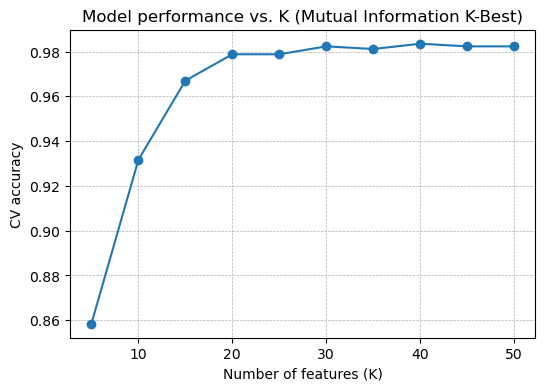

Saved MI K-curve to figures/mi_k_curve.png


In [136]:
# Keep only numeric features
X_num = X.select_dtypes(include=["number"])

# MI curve
ks, accs = accuracy_vs_k_MI(
    X_num, y,
    estimator=LogisticRegression(max_iter=2000, solver="lbfgs"),
    show=True, block=False, save_path="figures/mi_k_curve.png"
)
print("Saved MI K-curve to figures/mi_k_curve.png")


## Unsupervised Learning Methods

In all unsupervised models, a wrapper method is first applied to iterate over candidate feature subsets. The subset selected through this process is then used to train the unsupervised models. The results are as follows:

Convert Class Labels to Integers:

In [18]:
from sklearn.preprocessing import LabelEncoder

# Encode labels to integers for metrics
le = LabelEncoder()
y_train_num = le.fit_transform(y_train)
y_test_num = le.transform(y_test)

### K-Means Clustering

K-Means Wrapper Feature Subset Selection: Here we select a subset of the features that are suited for K-Means Clustering.

Step 1 | +gyro_y_dom_freq | acc_train=0.835 | acc_test=0.848
Step 2 | +acc_mag_iqr | acc_train=0.836 | acc_test=0.865
Step 3 | +acc_x_dom_freq | acc_train=0.855 | acc_test=0.883
Step 4 | +acc_mag_spec_centroid | acc_train=0.879 | acc_test=0.889
Step 5 | +gyro_y_iqr | acc_train=0.891 | acc_test=0.912
Step 6 | +acc_y_median | acc_train=0.892 | acc_test=0.918
Step 7 | +grav_corr_y_z | acc_train=0.893 | acc_test=0.906
Step 8 | +grav_x_spec_centroid | acc_train=0.883 | acc_test=0.883
Step 9 | +acc_mag_dom_freq | acc_train=0.891 | acc_test=0.901
Step 10 | +gyro_corr_y_z | acc_train=0.891 | acc_test=0.912
Step 11 | +acc_z_dom_freq | acc_train=0.899 | acc_test=0.912
Step 12 | +gyro_z_dom_freq | acc_train=0.891 | acc_test=0.889
Step 13 | +gyro_x_min | acc_train=0.889 | acc_test=0.865
Step 14 | +acc_z_min | acc_train=0.888 | acc_test=0.889
Step 15 | +acc_y_spec_entropy | acc_train=0.885 | acc_test=0.889
Best subset: ['gyro_y_dom_freq', 'acc_mag_iqr', 'acc_x_dom_freq', 'acc_mag_spec_centroid', 'g

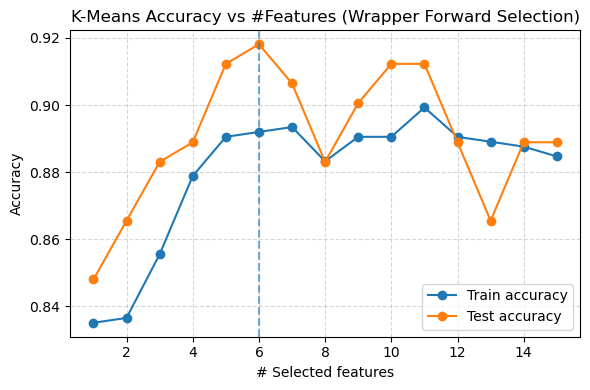

In [19]:
from sklearn.cluster import KMeans
from sklearn.metrics import confusion_matrix
from scipy.optimize import linear_sum_assignment

def cluster_accuracy(y_true, y_pred):
    """Accuracy after optimal cluster↔class matching (Hungarian)."""
    n = max(len(np.unique(y_true)), len(np.unique(y_pred)))
    cm = confusion_matrix(y_true, y_pred, labels=np.arange(n))
    r, c = linear_sum_assignment(cm.max() - cm)
    return cm[r, c].sum() / cm.sum()

def wrapper_kmeans_accuracy(X_train,
                            y_train,
                            X_test=None,
                            y_test=None,
                            *,
                            k=None,
                            n_features_to_select=15,
                            mode="fixed",          # "fixed" -> run full; "auto" -> early stop on no-improve
                            random_state=31,
                            kmeans_kwargs=None,
                            select_set=6):
    """
    Forward selection for K-Means scored by TRAIN accuracy (Hungarian).
    Runs up to n_features_to_select (or available features). Ignores `select_set`
    during the search; at the end returns the subset at that step size.

    Returns:
      X_train_best, X_test_best, chosen_features, chosen_acc_train, history
    """
    if k is None:
        k = len(np.unique(y_train))
    if kmeans_kwargs is None:
        kmeans_kwargs = {}

    features  = list(X_train.columns)
    max_steps = min(n_features_to_select, len(features))

    selected = []
    history  = []   # each: {"step", "feature_added", "acc_train", "acc_test"}

    # forward selection
    for step in range(1, max_steps + 1):
        trial_scores = []  # (acc_train, feature, acc_test)

        for f in features:
            if f in selected:
                continue

            subset = selected + [f]
            km = KMeans(n_clusters=k, random_state=random_state, **kmeans_kwargs)

            labels_tr = km.fit_predict(X_train[subset])
            acc_tr    = cluster_accuracy(y_train, labels_tr)

            acc_te = None
            if X_test is not None and y_test is not None:
                labels_te = km.predict(X_test[subset])
                acc_te    = cluster_accuracy(y_test, labels_te)

            trial_scores.append((acc_tr, f, acc_te))

        if not trial_scores:
            break

        # pick feature that maximizes TRAIN accuracy this step
        trial_scores.sort(key=lambda t: t[0], reverse=True)
        acc_tr, best_f, acc_te = trial_scores[0]
        selected.append(best_f)

        history.append({
            "step": step,
            "feature_added": best_f,
            "acc_train": float(acc_tr),
            "acc_test": None if acc_te is None else float(acc_te),
        })

        print(f"Step {step} | +{best_f} | acc_train={acc_tr:.3f}"
              + (f" | acc_test={acc_te:.3f}" if acc_te is not None else ""))

        # optional early stop if user asked for "auto"
        if mode == "auto":
            prev = history[-2]["acc_train"] if len(history) > 1 else -np.inf
            if acc_tr <= prev:
                print("No improvement on train; early stop.")
                break

    # ----- choose subset to RETURN -----
    if isinstance(select_set, int) and select_set > 0:
        chosen_step = min(select_set, len(history))
    else:
        # default: best TRAIN accuracy step
        chosen_step = int(np.argmax([h["acc_train"] for h in history])) + 1

    chosen_features  = [h["feature_added"] for h in history][:chosen_step]
    chosen_acc_train = history[chosen_step - 1]["acc_train"]

    X_train_best = X_train[chosen_features]
    X_test_best  = None if X_test is None else X_test[chosen_features]

    return X_train_best, X_test_best, chosen_features, float(chosen_acc_train), history



#///////////////////////////////////////////////////////////////////////////////////////

X_train_km_best, X_test_km_best, subset, best_acc, hist = wrapper_kmeans_accuracy(X_train_fs, 
                                                                                  y_train_num, 
                                                                                  X_test_fs, 
                                                                                  y_test_num,
                                                                                  k=5,
                                                                                  n_features_to_select=15,
                                                                                  mode="fixed",          # or "fixed"
                                                                                  random_state=31,
                                                                                  kmeans_kwargs={"n_init": 20, "max_iter": 300, "algorithm": "lloyd"},
                                                                                  select_set=6)

print("Best subset:", subset)
print("Best train accuracy:", best_acc)

# Plot
steps = [h["step"] for h in hist]
acc_train = [h["acc_train"] for h in hist]
acc_test  = [h["acc_test"] for h in hist] if hist[0]["acc_test"] is not None else None

plt.figure(figsize=(6,4))
plt.plot(steps, acc_train, marker='o', label="Train accuracy")
if acc_test is not None:
    plt.plot(steps, acc_test, marker='o', label="Test accuracy")
sel = len(subset)   # equals chosen_step
plt.axvline(sel, linestyle="--", alpha=0.6)
plt.xlabel("# Selected features")
plt.ylabel("Accuracy")
plt.title("K-Means Accuracy vs #Features (Wrapper Forward Selection)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

Using the reduced subset of features we train the K-Means Clustering Model


Train Accuracies for k=1..5: {1: 0.5620437956204379, 2: 0.872992700729927, 3: 0.8700729927007299, 4: 0.8583941605839416, 5: 0.891970802919708}

K-Means (k=5) - TRAIN Results:
  Accuracy: 0.8920
  F1 Score: 0.5666
  Kappa:    0.8161

K-Means (k=5) - TEST Results:
  Accuracy: 0.9181
  F1 Score: 0.6393
  Kappa:    0.8598


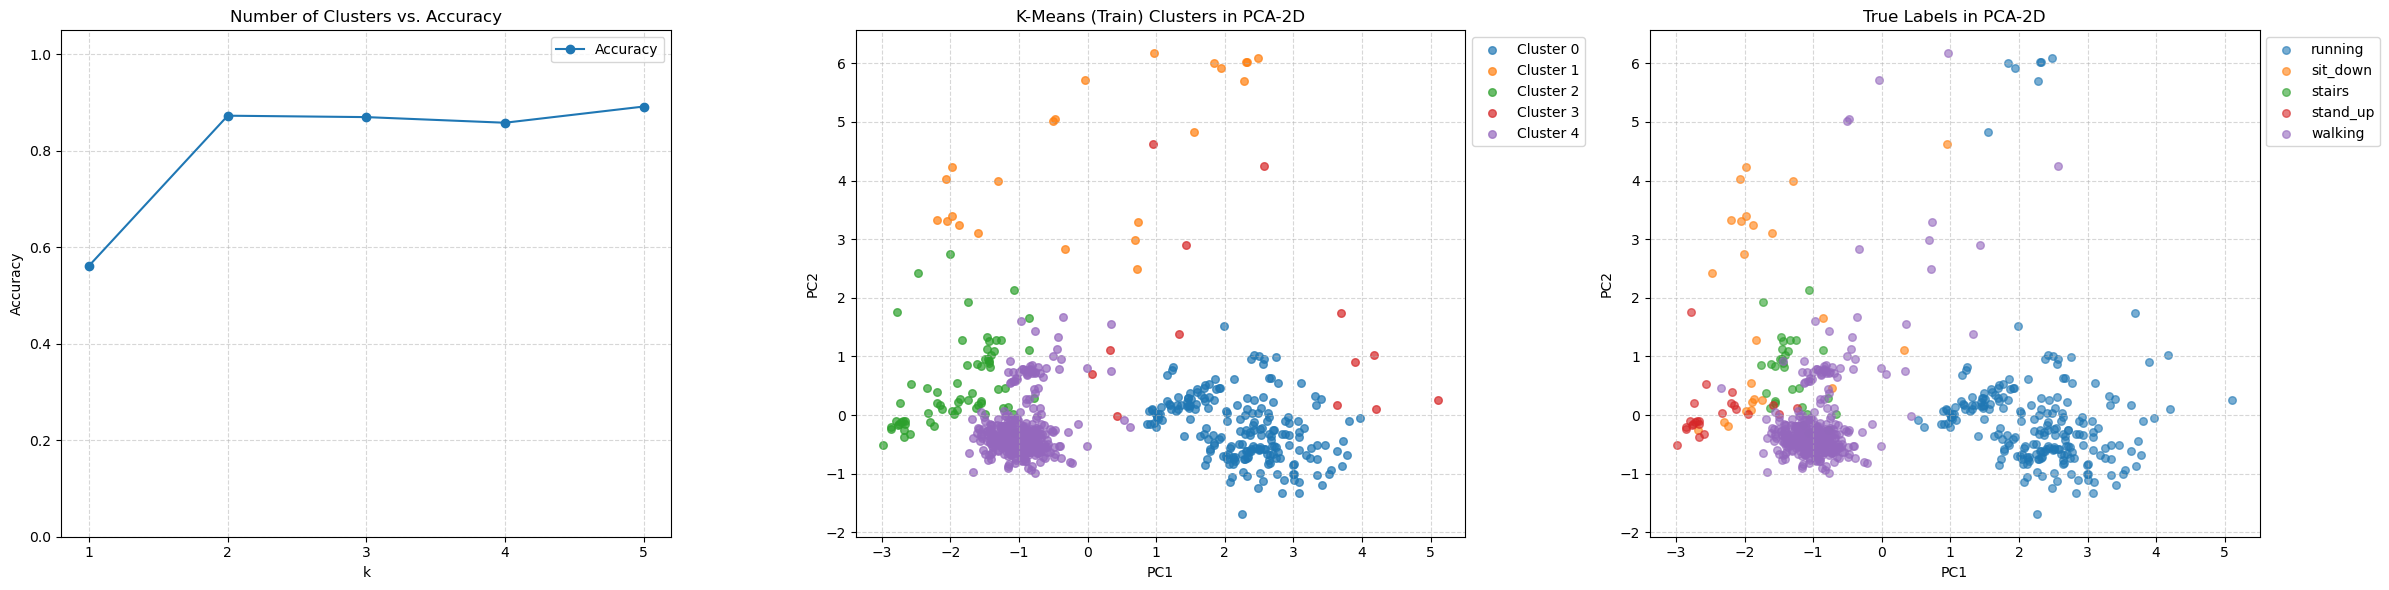

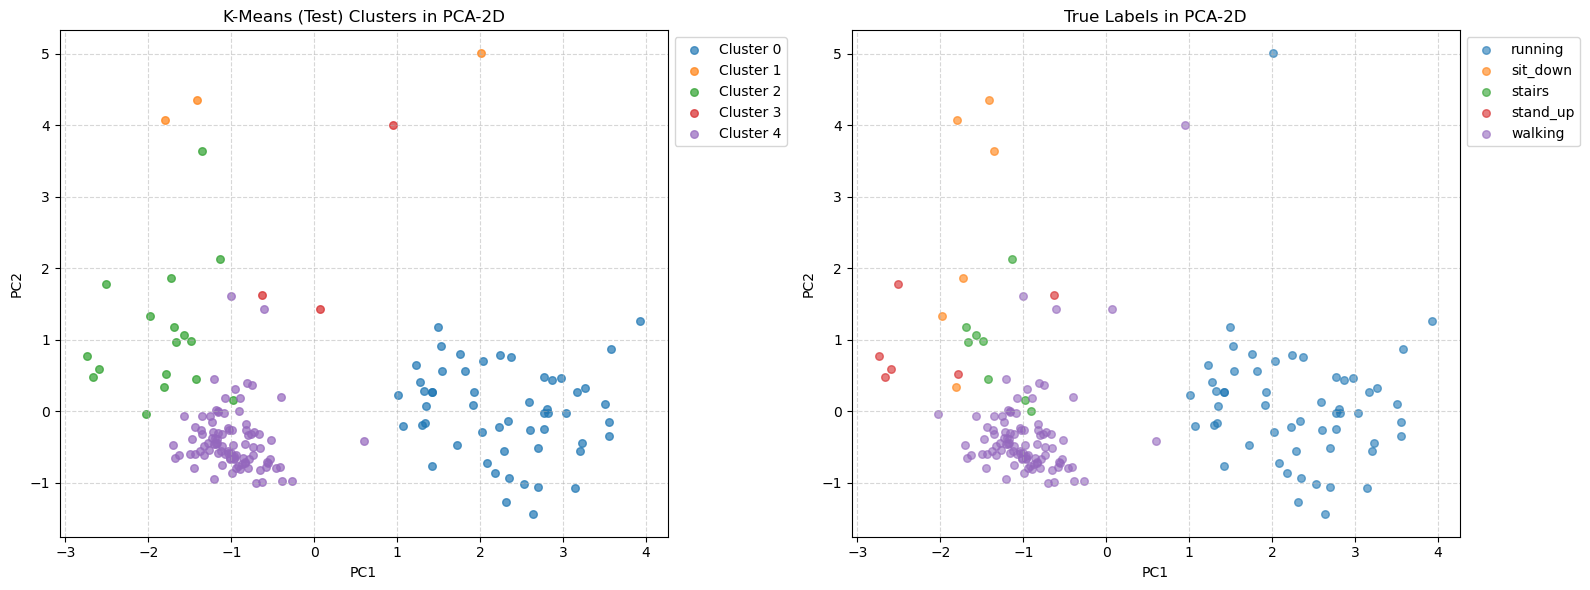

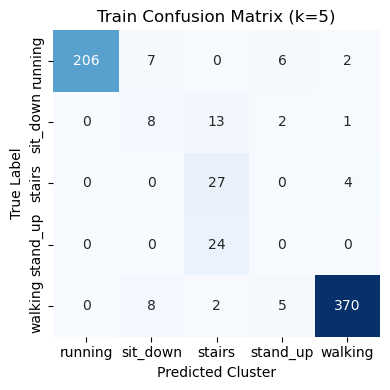

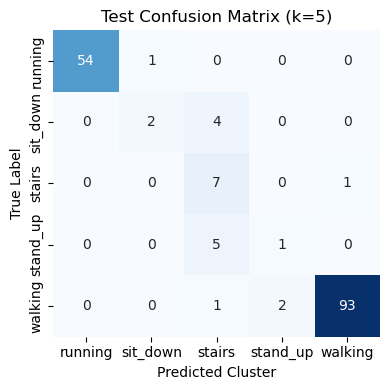

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, f1_score, cohen_kappa_score, confusion_matrix
from sklearn.decomposition import PCA
from scipy.optimize import linear_sum_assignment

def align_clusters(y_true, y_pred):
    """
    Align raw cluster IDs to ground-truth class IDs using Hungarian algorithm.
    """
    cm = confusion_matrix(y_true, y_pred)
    row_ind, col_ind = linear_sum_assignment(-cm)      # maximize matches
    mapping = {col: row for row, col in zip(row_ind, col_ind)}
    return np.array([mapping[c] for c in y_pred])


def eval_model(name, y_true, y_pred):
    """
    Print and return Accuracy, F1-macro and Cohen's Kappa.
    """
    acc = accuracy_score(y_true, y_pred)
    f1  = f1_score(y_true, y_pred, average="macro")
    kappa = cohen_kappa_score(y_true, y_pred)

    print(f"\n{name} Results:")
    print(f"  Accuracy: {acc:.4f}")
    print(f"  F1 Score: {f1:.4f}")
    print(f"  Kappa:    {kappa:.4f}")
    return acc, f1, kappa


def plot_clustering_results(model_name, X_data, y_true, le,
                            cluster_range, accuracies, clusters_k,
                            show_k_vs_acc=True):
    pca = PCA(n_components=2, random_state=42)
    X_pca = pca.fit_transform(X_data)

    # If we don't want the first plot, make only 2 subplots
    n_cols = 3 if show_k_vs_acc else 2
    fig, axs = plt.subplots(1, n_cols, figsize=(8*n_cols, 6))

    idx = 0
    # --- 1) k vs Accuracy ---
    if show_k_vs_acc:
        axs[0].plot(list(cluster_range), accuracies, marker='o', label="Accuracy")
        axs[0].set_title("Number of Clusters vs. Accuracy")
        axs[0].set_xlabel("k")
        axs[0].set_ylabel("Accuracy")
        axs[0].set_xticks(list(cluster_range))
        axs[0].set_ylim(0, 1.05)
        axs[0].grid(True, linestyle='--', alpha=0.5)
        axs[0].legend()
        idx = 1

    # --- 2) Cluster assignments in PCA space ---
    for c in np.unique(clusters_k):
        pts = X_pca[clusters_k == c]
        axs[idx].scatter(pts[:, 0], pts[:, 1], label=f"Cluster {c}", alpha=0.7, s=30)
    axs[idx].set_title(f"{model_name} Clusters in PCA-2D")
    axs[idx].set_xlabel("PC1")
    axs[idx].set_ylabel("PC2")
    axs[idx].legend(loc='upper left', bbox_to_anchor=(1, 1))
    axs[idx].grid(True, linestyle='--', alpha=0.5)

    # --- 3) True labels in PCA space ---
    for lab in np.unique(y_true):
        pts = X_pca[y_true == lab]
        name = str(le.inverse_transform([lab])[0]) if hasattr(le, "inverse_transform") else f"Class {lab}"
        axs[idx+1].scatter(pts[:, 0], pts[:, 1], label=name, alpha=0.6, s=30)
    axs[idx+1].set_title("True Labels in PCA-2D")
    axs[idx+1].set_xlabel("PC1")
    axs[idx+1].set_ylabel("PC2")
    axs[idx+1].legend(loc='upper left', bbox_to_anchor=(1, 1))
    axs[idx+1].grid(True, linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.show()

def plot_confusion_matrix(cm, le, title, cmap='Blues'):
    """
    Pretty confusion matrix plot.
    """
    plt.figure(figsize=(4,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap,
                xticklabels=le.classes_, yticklabels=le.classes_, cbar=False)
    plt.xlabel("Predicted Cluster")
    plt.ylabel("True Label")
    plt.title(title)
    plt.tight_layout()
    plt.show()

# KMeans for k = 1..5 on TRAIN
cluster_range = range(1, 6)
kmeans_results = []

for k in cluster_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    clusters = km.fit_predict(X_train_km_best)
    kmeans_results.append(clusters)

# Compute train accuracies for each k
accuracies = []
for clusters in kmeans_results:
    aligned = align_clusters(y_train_num, clusters)
    accuracies.append(accuracy_score(y_train_num, aligned))

print("\nTrain Accuracies for k=1..5:", dict(zip(cluster_range, accuracies)))

# Pick k = 5 (final model), evaluate on TRAIN
k_final = 5
km_final = KMeans(n_clusters=k_final, random_state=42, n_init=10)
clusters_train = km_final.fit_predict(X_train_km_best)
y_train_aligned = align_clusters(y_train_num, clusters_train)

acc_train, f1_train, kappa_train = eval_model("K-Means (k=5) - TRAIN", y_train_num, y_train_aligned)

# Predict & evaluate on TEST
clusters_test = km_final.predict(X_test_km_best)
y_test_aligned = align_clusters(y_test_num, clusters_test)

acc_test, f1_test, kappa_test = eval_model("K-Means (k=5) - TEST", y_test_num, y_test_aligned)

# plots
plot_clustering_results("K-Means (Train)",
                        X_train_km_best, y_train_num, le,
                        cluster_range, accuracies, y_train_aligned,
                        show_k_vs_acc=True)

plot_clustering_results("K-Means (Test)",
                        X_test_km_best, y_test_num, le,
                        [5], [acc_test], y_test_aligned,
                        show_k_vs_acc=False)


# Confusion Matrices
cm_train = confusion_matrix(y_train_num, y_train_aligned)
plot_confusion_matrix(cm_train, le, "Train Confusion Matrix (k=5)", cmap='Blues')

cm_test = confusion_matrix(y_test_num, y_test_aligned)
plot_confusion_matrix(cm_test, le, "Test Confusion Matrix (k=5)", cmap='Blues')


### Fuzzy C-Means Clustering

Fuzzy C-Means Wrapper Feature Subset Selection: Here we select a subset of the features that are suited for Fuzzy C-Means Clustering.

Step 1 | +gyro_y_dom_freq | acc_train=0.835 | acc_test=0.848
Step 2 | +acc_x_dom_freq | acc_train=0.828 | acc_test=0.860
Step 3 | +gyro_z_dom_freq | acc_train=0.815 | acc_test=0.795
Step 4 | +gyro_corr_y_z | acc_train=0.823 | acc_test=0.807
Step 5 | +grav_x_dom_freq | acc_train=0.781 | acc_test=0.772
Step 6 | +grav_corr_y_z | acc_train=0.799 | acc_test=0.795
Step 7 | +grav_x_max | acc_train=0.777 | acc_test=0.778
Step 8 | +grav_x_spec_centroid | acc_train=0.790 | acc_test=0.784
Step 9 | +gyro_corr_x_z | acc_train=0.784 | acc_test=0.807
Step 10 | +acc_y_spec_entropy | acc_train=0.800 | acc_test=0.807
Step 11 | +acc_mag_iqr | acc_train=0.803 | acc_test=0.807
Step 12 | +gyro_y_iqr | acc_train=0.793 | acc_test=0.807
Step 13 | +acc_z_dom_freq | acc_train=0.800 | acc_test=0.813
Step 14 | +gyro_z_kurtosis | acc_train=0.781 | acc_test=0.789
Step 15 | +acc_corr_y_z | acc_train=0.708 | acc_test=0.702

FCM - Returned subset size: 6
FCM - Returned subset: ['gyro_y_dom_freq', 'acc_x_dom_freq', 'gyr

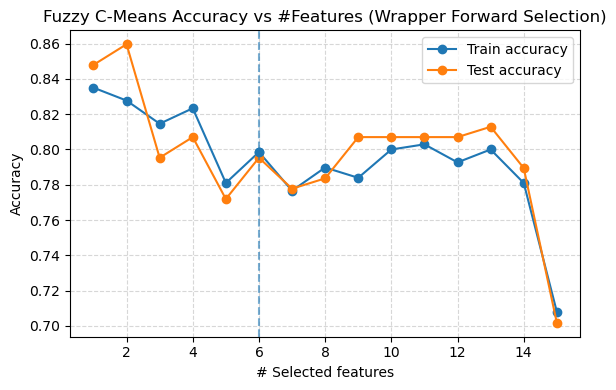

In [21]:
import skfuzzy as fuzz

def _fcm_memberships_from_centers(X, centers, m=2.0, eps=1e-12):
    """
    Compute FCM memberships for X given learned centers (no refit).
    Returns U with shape (c, n_samples).
    """
    X = np.asarray(X)
    C = np.asarray(centers)
    d = np.linalg.norm(X[None, :, :] - C[:, None, :], axis=2) + eps  # (c, n)

    exact = np.isclose(d, eps)
    if exact.any():
        U = np.zeros_like(d)
        closest = np.argmin(d, axis=0)
        U[closest, np.arange(X.shape[0])] = 1.0
        mask = (U.sum(axis=0) == 0)
        if mask.any():
            dm = d[:, mask]
            p = 2.0 / (m - 1.0)
            ratio = (dm[:, None, :] / dm[None, :, :]) ** p
            denom = ratio.sum(axis=1)
            U[:, mask] = 1.0 / denom
        return U

    p = 2.0 / (m - 1.0)
    ratio = (d[:, None, :] / d[None, :, :]) ** p
    denom = ratio.sum(axis=1)
    return 1.0 / denom


def wrapper_fcm_accuracy(X_train,
                         y_train,
                         X_test=None,
                         y_test=None,
                         *,
                         k=5,
                         n_features_to_select=15,
                         mode="fixed",           # "fixed" -> run full; "auto" -> early stop on no-improve
                         m=2.0,
                         error=0.005,
                         maxiter=1000,
                         random_state=None,
                         select_set=None):
    """
    Forward selection for FCM scored by TRAIN accuracy (Hungarian).
    Runs up to n_features_to_select (or available features). Ignores `select_set`
    during the search; at the end returns the subset at that step size.

    Returns:
      X_train_best, X_test_best, best_subset, best_acc_train_at_selected_step, history
    """
    if k is None:
        k = len(np.unique(y_train))

    # RNG for reproducible U0 initializations
    rng = np.random.RandomState(random_state) if random_state is not None else None

    features = list(X_train.columns)
    max_steps = min(n_features_to_select, len(features))

    selected = []
    history  = []  # each item: step, feature_added, acc_train, (optional) acc_test

    # forward selection
    for step in range(1, max_steps + 1):
        trial_scores = []  # (acc_train, feature, acc_test)

        for f in features:
            if f in selected:
                continue
            subset = selected + [f]
            Xtr = X_train[subset].to_numpy().T  # (features, samples)

            # Reproducible random soft membership init U0 if random_state provided
            if rng is not None:
                U0 = rng.rand(k, Xtr.shape[1])
                U0 /= U0.sum(axis=0, keepdims=True)  # columns sum to 1
            else:
                U0 = None

            cntr, Utr, *_ = fuzz.cluster.cmeans(
                Xtr, c=k, m=m, error=error, maxiter=maxiter, init=U0
            )
            labels_tr = Utr.argmax(axis=0)
            acc_tr = cluster_accuracy(y_train, labels_tr)

            acc_te = None
            if X_test is not None and y_test is not None:
                Ute = _fcm_memberships_from_centers(X_test[subset].to_numpy(), cntr, m=m)
                labels_te = Ute.argmax(axis=0)
                acc_te = cluster_accuracy(y_test, labels_te)

            trial_scores.append((acc_tr, f, acc_te))

        # pick feature giving highest TRAIN accuracy this step
        trial_scores.sort(key=lambda t: t[0], reverse=True)
        acc_tr, best_f, acc_te = trial_scores[0]
        selected.append(best_f)
        history.append({
            "step": step,
            "feature_added": best_f,
            "acc_train": float(acc_tr),
            "acc_test": None if acc_te is None else float(acc_te),
        })
        print(f"Step {step} | +{best_f} | acc_train={acc_tr:.3f}"
              + (f" | acc_test={acc_te:.3f}" if acc_te is not None else ""))

        # optional early stop only if user asked for "auto"
        if mode == "auto":
            prev = history[-2]["acc_train"] if len(history) > 1 else -np.inf
            if acc_tr <= prev:
                print("No improvement on train; early stop.")
                break

    # choose subset to RETURN (select_set = integer step)
    if isinstance(select_set, int) and select_set > 0:
        chosen_step = min(select_set, len(history))
    else:
        # if not specified, default to best TRAIN accuracy seen
        chosen_step = int(np.argmax([h["acc_train"] for h in history])) + 1

    chosen_features  = [h["feature_added"] for h in history][:chosen_step]
    chosen_acc_train = history[chosen_step - 1]["acc_train"]

    X_train_best = X_train[chosen_features]
    X_test_best  = None if X_test is None else X_test[chosen_features]
    return X_train_best, X_test_best, chosen_features, float(chosen_acc_train), history


X_train_fcm_best, X_test_fcm_best, subset_fcm, best_acc_fcm, hist_fcm = wrapper_fcm_accuracy(X_train_fs,
                                                                                             y_train_num,
                                                                                             X_test=X_test_fs,
                                                                                             y_test=y_test_num,
                                                                                             k=5,
                                                                                             n_features_to_select=15,
                                                                                             mode="fixed",      # runs the whole search
                                                                                             m=2.0,
                                                                                             error=0.005,
                                                                                             maxiter=1000,
                                                                                             random_state=99,
                                                                                             select_set=6)
print("\nFCM - Returned subset size:", len(subset_fcm))
print("FCM - Returned subset:", subset_fcm)
print("FCM - Train accuracy at that step:", best_acc_fcm)

# Plot: #features vs accuracy from history
steps     = [h["step"] for h in hist_fcm]
acc_train = [h["acc_train"] for h in hist_fcm]
has_test  = (hist_fcm and hist_fcm[0]["acc_test"] is not None)
acc_test  = [h["acc_test"] for h in hist_fcm] if has_test else None

plt.figure(figsize=(6,4))
plt.plot(steps, acc_train, marker='o', label="Train accuracy")
if has_test:
    plt.plot(steps, acc_test, marker='o', label="Test accuracy")
# highlight the selected step
sel = len(subset_fcm)   # equals chosen_step
plt.axvline(sel, linestyle="--", alpha=0.6)
plt.scatter([sel], [acc_train[sel-1]], zorder=3)
plt.xlabel("# Selected features")
plt.ylabel("Accuracy")
plt.title("Fuzzy C-Means Accuracy vs #Features (Wrapper Forward Selection)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()


Using the reduced subset of features we train the Fuzzy C-Mean Clustering Model


Train Accuracies for k=1..5 (FCM): {1: 0.5620437956204379, 2: 0.8656934306569343, 3: 0.8014598540145985, 4: 0.8262773722627738, 5: 0.7985401459854015}

Fuzzy C-Means (k=5) - TRAIN Results:
  Accuracy: 0.7985
  F1 Score: 0.5382
  Kappa:    0.6807

Fuzzy C-Means (k=5) - TEST Results:
  Accuracy: 0.7953
  F1 Score: 0.5288
  Kappa:    0.6735


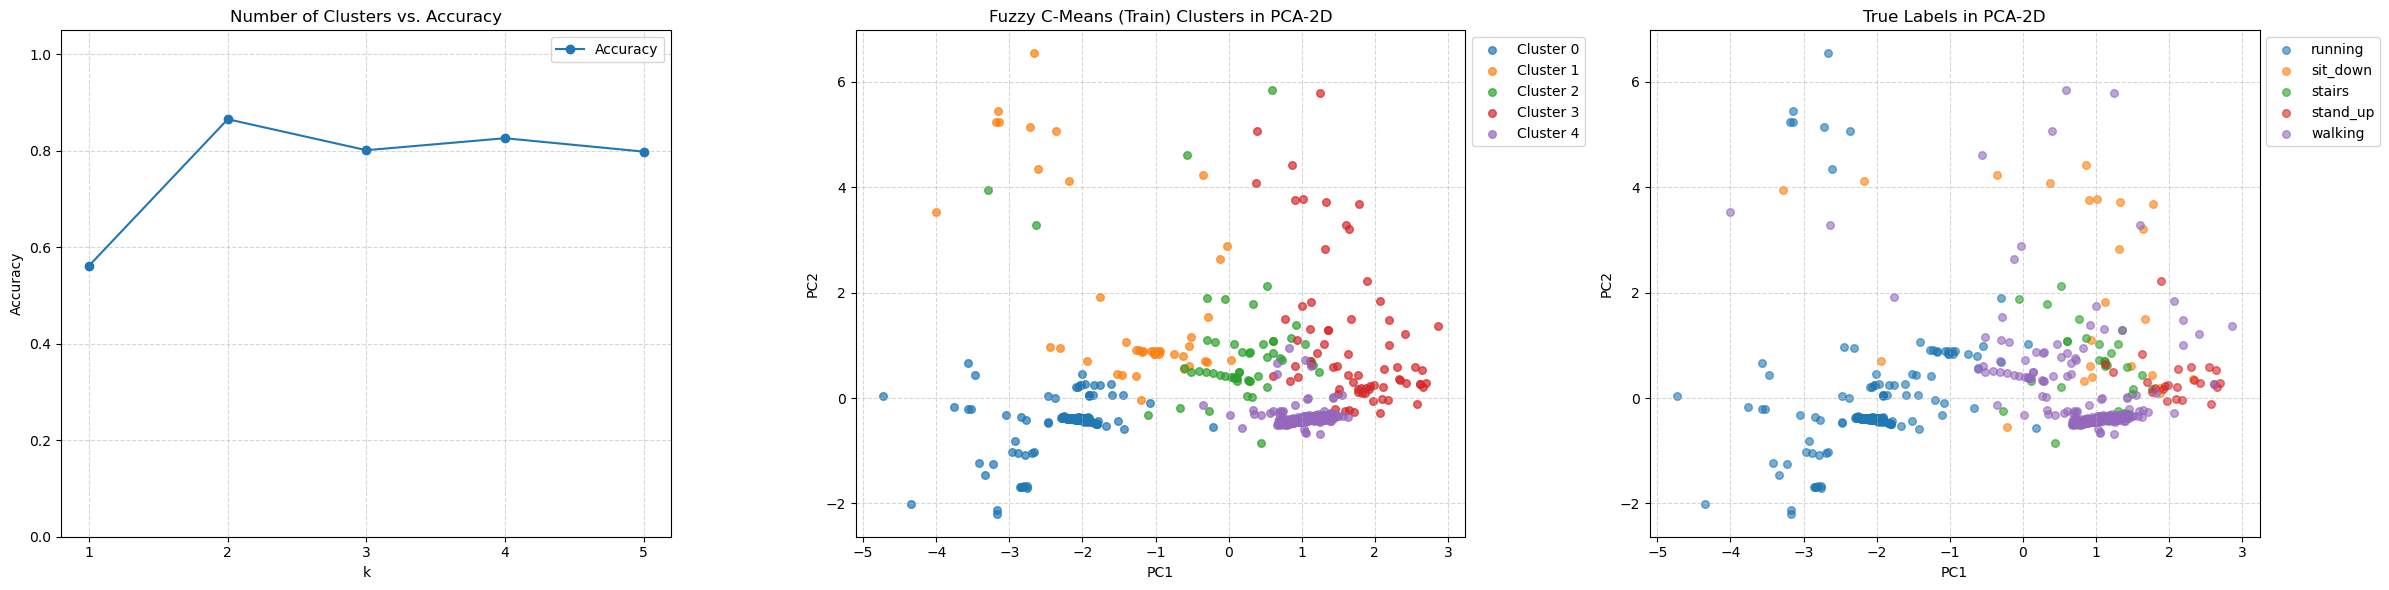

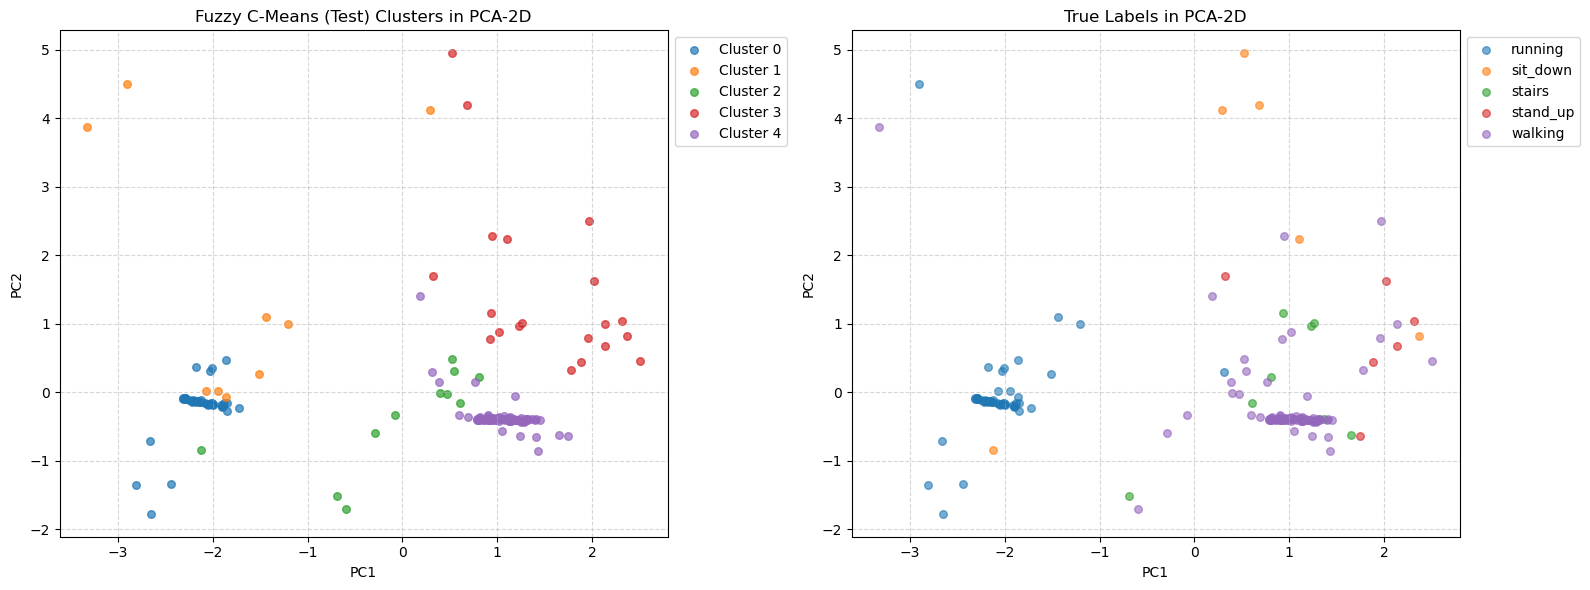

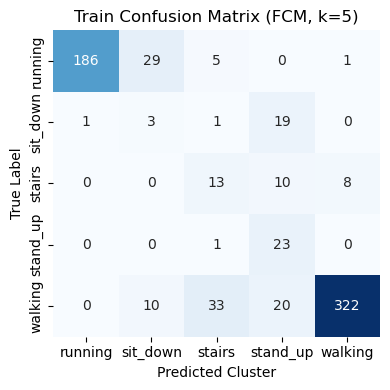

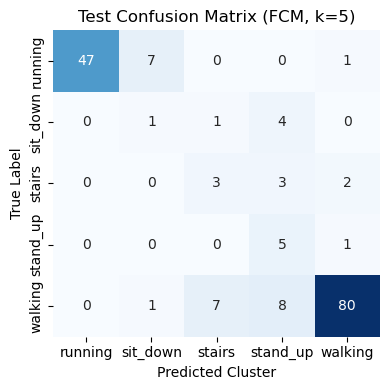

In [22]:
cluster_range = range(1, 6)
fcm_results = []

# Reproducible init for cmeans
rng = np.random.RandomState(42)

for k in cluster_range:
    # skfuzzy.cmeans expects (features, samples)
    Xtr = X_train_fcm_best.to_numpy().T
    # reproducible random membership init U0
    U0 = rng.rand(k, Xtr.shape[1])
    U0 /= U0.sum(axis=0, keepdims=True)

    cntr, Utr, _, _, _, _, _ = fuzz.cluster.cmeans(Xtr, c=k, m=2.0, error=0.005, maxiter=1000, init=U0)
    clusters = Utr.argmax(axis=0)  # hard labels
    fcm_results.append(clusters)

# Train accuracies for each k (after alignment)
accuracies = []
for clusters in fcm_results:
    aligned = align_clusters(y_train_num, clusters)
    accuracies.append(accuracy_score(y_train_num, aligned))

print("\nTrain Accuracies for k=1..5 (FCM):", dict(zip(cluster_range, accuracies)))

# Final k = 5: fit on TRAIN, predict on TEST
k_final = 5

# Fit FCM on train (k=5) with reproducible init
Xtr = X_train_fcm_best.to_numpy().T
U0 = rng.rand(k_final, Xtr.shape[1]); U0 /= U0.sum(axis=0, keepdims=True)
cntr_final, Utr_final, _, _, _, _, _ = fuzz.cluster.cmeans(Xtr, c=k_final, m=2.0, error=0.005, maxiter=1000, init=U0)

clusters_train = Utr_final.argmax(axis=0)
y_train_aligned = align_clusters(y_train_num, clusters_train)
acc_train, f1_train, kappa_train = eval_model("Fuzzy C-Means (k=5) - TRAIN", y_train_num, y_train_aligned)

# Predict clusters for TEST using learned centers
Ute_final = _fcm_memberships_from_centers(X_test_fcm_best.to_numpy(), cntr_final, m=2.0)
clusters_test = Ute_final.argmax(axis=0)
y_test_aligned = align_clusters(y_test_num, clusters_test)
acc_test, f1_test, kappa_test = eval_model("Fuzzy C-Means (k=5) - TEST", y_test_num, y_test_aligned)

# Plot
plot_clustering_results("Fuzzy C-Means (Train)",
                        X_train_fcm_best, y_train_num, le,
                        cluster_range, accuracies, y_train_aligned,
                        show_k_vs_acc=True)

plot_clustering_results("Fuzzy C-Means (Test)",
                        X_test_fcm_best, y_test_num, le,
                        [k_final], [acc_test], y_test_aligned,
                        show_k_vs_acc=False)

# Confusion Matrices
cm_train = confusion_matrix(y_train_num, y_train_aligned)
plot_confusion_matrix(cm_train, le, "Train Confusion Matrix (FCM, k=5)", cmap='Blues')

cm_test = confusion_matrix(y_test_num, y_test_aligned)
plot_confusion_matrix(cm_test, le, "Test Confusion Matrix (FCM, k=5)", cmap='Blues')


### Gaussian Mixture Models (GMMs)

Gaussian Mixture Model Wrapper Feature Subset Selection: Here we select a subset of the features that are suited for GMM.

Step 1 | +gyro_z_dom_freq | acc_train=0.842 | acc_test=0.825
Step 2 | +acc_y_median | acc_train=0.844 | acc_test=0.836
Step 3 | +gyro_x_min | acc_train=0.860 | acc_test=0.848
Step 4 | +acc_mag_dom_freq | acc_train=0.857 | acc_test=0.836
Step 5 | +acc_z_dom_freq | acc_train=0.860 | acc_test=0.860
Step 6 | +acc_mag_iqr | acc_train=0.886 | acc_test=0.889
Step 7 | +grav_corr_y_z | acc_train=0.885 | acc_test=0.883
Step 8 | +acc_z_min | acc_train=0.883 | acc_test=0.877
Step 9 | +grav_x_iqr | acc_train=0.863 | acc_test=0.860
Step 10 | +grav_y_dom_freq | acc_train=0.851 | acc_test=0.836
Step 11 | +gyro_x_dom_freq | acc_train=0.863 | acc_test=0.848
Step 12 | +gyro_mag_spec_centroid | acc_train=0.869 | acc_test=0.860
Step 13 | +acc_y_spec_entropy | acc_train=0.866 | acc_test=0.860
Step 14 | +gyro_z_spec_centroid | acc_train=0.854 | acc_test=0.848
Step 15 | +grav_x_spec_centroid | acc_train=0.869 | acc_test=0.860

GMM - Returned subset size: 6
GMM - Returned subset: ['gyro_z_dom_freq', 'acc_y_med

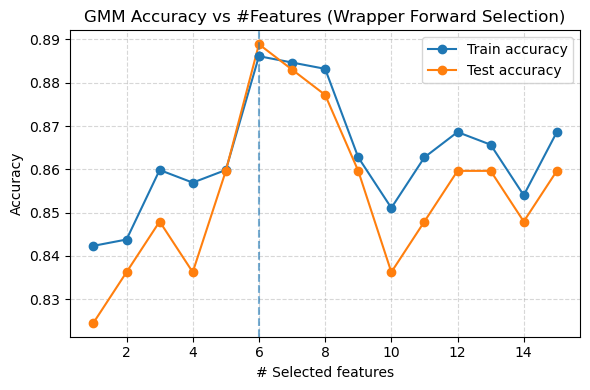

In [23]:
from sklearn.mixture import GaussianMixture

def wrapper_gmm_accuracy(X_train,
                         y_train,
                         X_test=None,
                         y_test=None,
                         *,
                         k=5,
                         n_features_to_select=15,
                         mode="fixed",              # "fixed" -> run full; "auto" -> early stop on no-improve
                         random_state=42,
                         select_set=6,           # INT: subset size to RETURN at the end (e.g., 6)
                         gmm_kwargs=None):
    """
    Forward selection for Gaussian Mixture Models scored by TRAIN accuracy (Hungarian).
    Runs up to n_features_to_select (or available features). Ignores `select_set`
    during the search; at the end returns the subset at that step size.

    Returns:
      X_train_best, X_test_best, chosen_features, chosen_acc_train, history
    """
    if k is None:
        k = len(np.unique(y_train))
    if gmm_kwargs is None:
        gmm_kwargs = {}
    features  = list(X_train.columns)
    max_steps = min(n_features_to_select, len(features))
    selected = []
    history  = []   # each item: {"step", "feature_added", "acc_train", "acc_test"}

    # forward selection
    for step in range(1, max_steps + 1):
        trial_scores = []  # (acc_train, feature, acc_test)
        for f in features:
            if f in selected:
                continue
            subset = selected + [f]
            gmm = GaussianMixture(n_components=k, random_state=random_state, **gmm_kwargs)
            # Fit on train subset; labels = argmax posterior (predict)
            gmm.fit(X_train[subset])
            labels_tr = gmm.predict(X_train[subset])
            acc_tr    = cluster_accuracy(y_train, labels_tr)
            acc_te = None
            if X_test is not None and y_test is not None:
                labels_te = gmm.predict(X_test[subset])
                acc_te    = cluster_accuracy(y_test, labels_te)
            trial_scores.append((acc_tr, f, acc_te))
        if not trial_scores:
            break
        # pick feature that maximizes TRAIN accuracy this step
        trial_scores.sort(key=lambda t: t[0], reverse=True)
        acc_tr, best_f, acc_te = trial_scores[0]
        selected.append(best_f)
        history.append({
            "step": step,
            "feature_added": best_f,
            "acc_train": float(acc_tr),
            "acc_test": None if acc_te is None else float(acc_te)})
        print(f"Step {step} | +{best_f} | acc_train={acc_tr:.3f}"
              + (f" | acc_test={acc_te:.3f}" if acc_te is not None else ""))
        # optional early stop if user asked for "auto"
        if mode == "auto":
            prev = history[-2]["acc_train"] if len(history) > 1 else -np.inf
            if acc_tr <= prev:
                print("No improvement on train; early stop.")
                break
    if isinstance(select_set, int) and select_set > 0:
        chosen_step = min(select_set, len(history))
    else:
        # default: best TRAIN accuracy step
        chosen_step = int(np.argmax([h["acc_train"] for h in history])) + 1

    chosen_features  = [h["feature_added"] for h in history][:chosen_step]
    chosen_acc_train = history[chosen_step - 1]["acc_train"]
    X_train_best = X_train[chosen_features]
    X_test_best  = None if X_test is None else X_test[chosen_features]
    return X_train_best, X_test_best, chosen_features, float(chosen_acc_train), history


X_train_gmm_best, X_test_gmm_best, subset_gmm, best_acc_gmm, hist_gmm = wrapper_gmm_accuracy(X_train_fs,
                                                                                             y_train_num,
                                                                                             X_test=X_test_fs,
                                                                                             y_test=y_test_num,
                                                                                             k=5,
                                                                                             n_features_to_select=15,
                                                                                             mode="fixed",
                                                                                             random_state=1,
                                                                                             select_set=6,           # <- return the subset at step 6
                                                                                             gmm_kwargs={"covariance_type": "full",
                                                                                                         "n_init": 1,                
                                                                                                         "reg_covar": 1e-6})
print("\nGMM - Returned subset size:", len(subset_gmm))
print("GMM - Returned subset:", subset_gmm)
print("GMM - Train accuracy at that step:", best_acc_gmm)

# Plot: #features vs accuracy from history
steps     = [h["step"] for h in hist_gmm]
acc_train = [h["acc_train"] for h in hist_gmm]
has_test  = (hist_gmm and hist_gmm[0]["acc_test"] is not None)
acc_test  = [h["acc_test"] for h in hist_gmm] if has_test else None

plt.figure(figsize=(6,4))
plt.plot(steps, acc_train, marker='o', label="Train accuracy")
if has_test:
    plt.plot(steps, acc_test, marker='o', label="Test accuracy")
# highlight the selected step
sel = len(subset_gmm)   # equals chosen_step
plt.axvline(sel, linestyle="--", alpha=0.6)
plt.scatter([sel], [acc_train[sel-1]], zorder=3)
plt.xlabel("# Selected features")
plt.ylabel("Accuracy")
plt.title("GMM Accuracy vs #Features (Wrapper Forward Selection)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()


Using the reduced subset of features we train the GMM Clustering Model


Train Accuracies for k=1..5 (GMM): {1: 0.5620437956204379, 2: 0.8846715328467153, 3: 0.8452554744525548, 4: 0.7635036496350365, 5: 0.672992700729927}

GMM (k=5) - TRAIN Results:
  Accuracy: 0.7650
  F1 Score: 0.4354
  Kappa:    0.6058

GMM (k=5) - TEST Results:
  Accuracy: 0.7544
  F1 Score: 0.4161
  Kappa:    0.5907


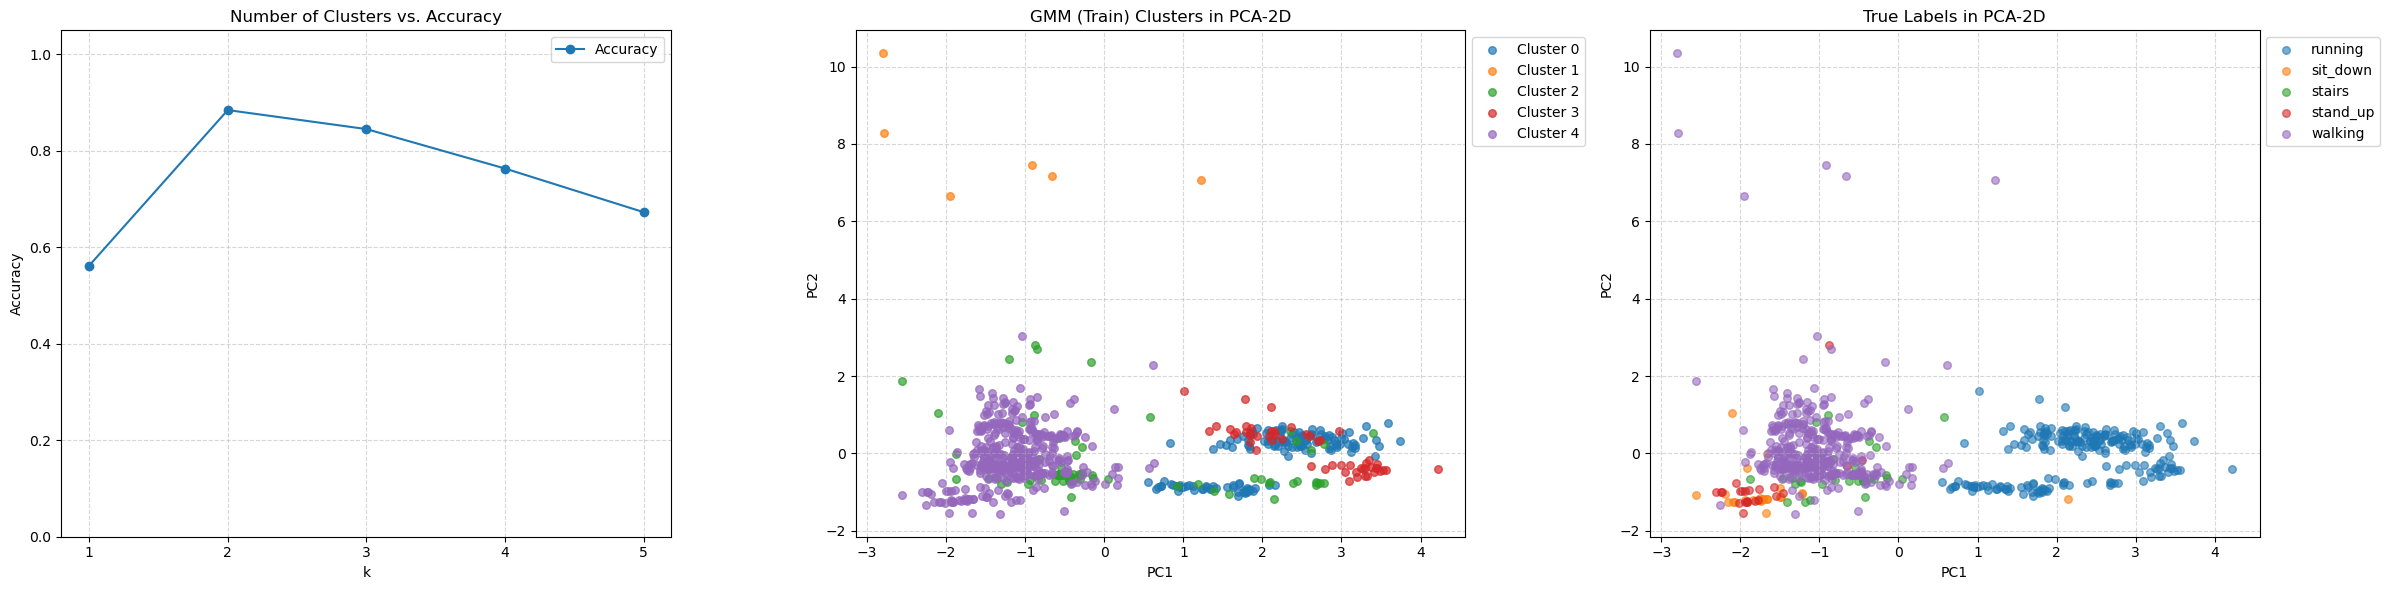

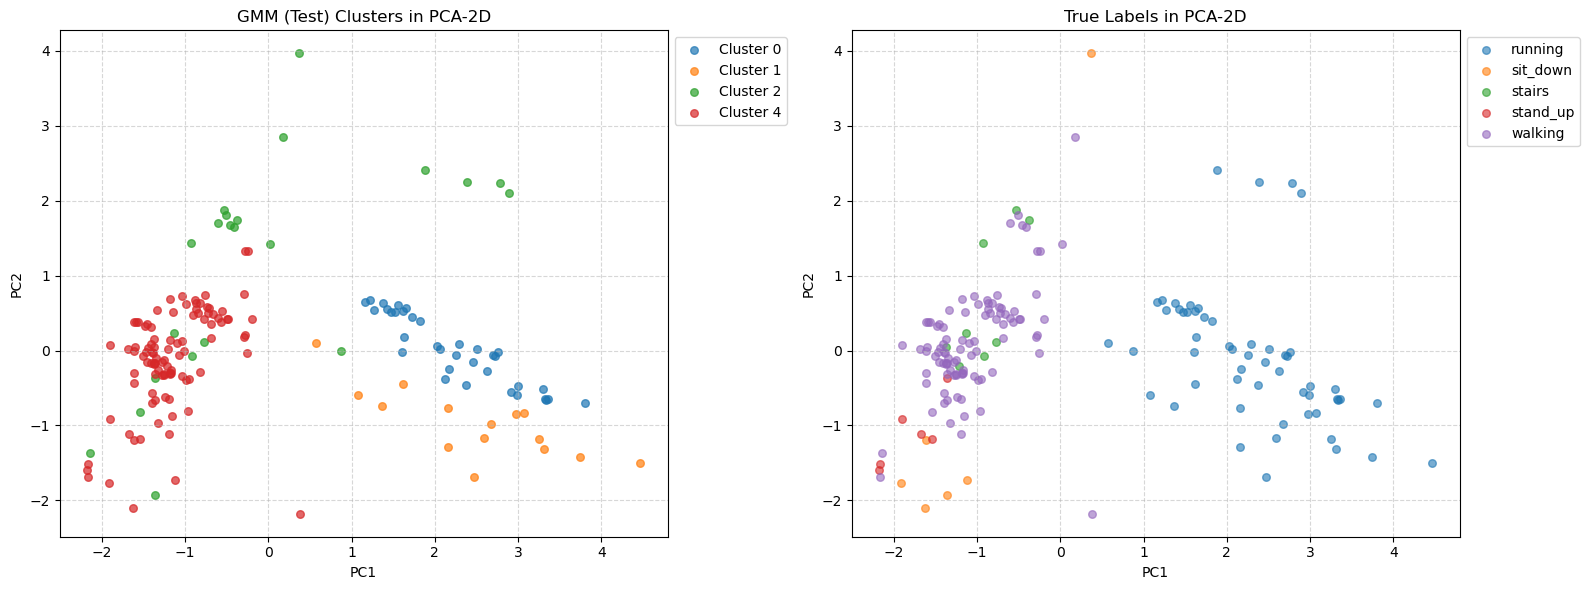

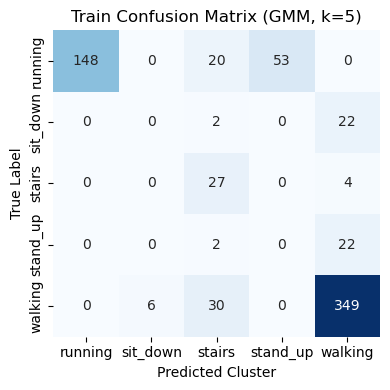

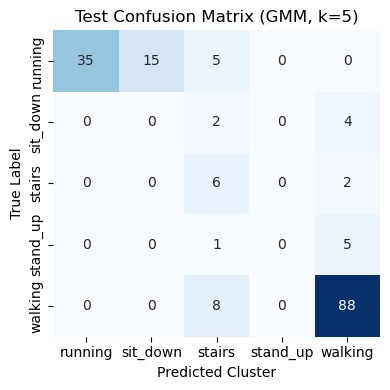

In [24]:
import numpy as np
from sklearn.mixture import GaussianMixture
from sklearn.metrics import accuracy_score, confusion_matrix

cluster_range = range(1, 6)
gmm_results = []

rng = np.random.RandomState(42)  # for reproducibility of GMM init params

for k in cluster_range:
    gmm = GaussianMixture(
        n_components=k,
        covariance_type="full",
        reg_covar=1e-6,           
        n_init=10,                
        random_state=42
    )
    gmm.fit(X_train_gmm_best)
    clusters = gmm.predict(X_train_gmm_best)
    gmm_results.append(clusters)

# Train accuracies
accuracies = []
for clusters in gmm_results:
    aligned = align_clusters(y_train_num, clusters)
    accuracies.append(accuracy_score(y_train_num, aligned))

print("\nTrain Accuracies for k=1..5 (GMM):", dict(zip(cluster_range, accuracies)))

# Final k = 5: fit on TRAIN, predict on TEST
k_final = 5
gmm_final = GaussianMixture(
    n_components=k_final,
    covariance_type="full",
    reg_covar=1e-6,
    n_init=1,
    random_state=42
)
gmm_final.fit(X_train_gmm_best)

# Train evaluation
clusters_train = gmm_final.predict(X_train_gmm_best)
y_train_aligned = align_clusters(y_train_num, clusters_train)
acc_train, f1_train, kappa_train = eval_model("GMM (k=5) - TRAIN", y_train_num, y_train_aligned)

# Test evaluation
clusters_test = gmm_final.predict(X_test_gmm_best)
y_test_aligned = align_clusters(y_test_num, clusters_test)
acc_test, f1_test, kappa_test = eval_model("GMM (k=5) - TEST", y_test_num, y_test_aligned)

# Plots
plot_clustering_results("GMM (Train)",
                        X_train_gmm_best, y_train_num, le,
                        cluster_range, accuracies, y_train_aligned,
                        show_k_vs_acc=True)

plot_clustering_results("GMM (Test)",
                        X_test_gmm_best, y_test_num, le,
                        [k_final], [acc_test], y_test_aligned,
                        show_k_vs_acc=False)

# Confusion Matrices
cm_train = confusion_matrix(y_train_num, y_train_aligned)
plot_confusion_matrix(cm_train, le, "Train Confusion Matrix (GMM, k=5)", cmap='Blues')

cm_test = confusion_matrix(y_test_num, y_test_aligned)
plot_confusion_matrix(cm_test, le, "Test Confusion Matrix (GMM, k=5)", cmap='Blues')